# Model 2 IMPROVED: RO rejection & permeate flow vs TMP.

With only 3 calibration points (30/40/50 bar), no ML model can be honestly "trained" —
a degree-2 polynomial through 3 points has zero residual (R2 is meaningless) and, more
importantly, is UNCONSTRAINED outside [30,50] bar: it can curve back down or blow up
for pressures a real membrane would never show.

Upgrade: replace the polynomial with the solution-diffusion membrane transport model
used throughout the RO literature (and cited implicitly in the paper itself, Section
2.1, Eq. 1 area):
    Jw  = A * (deltaP - deltaPi)              (water flux, ~linear in net driving pressure)
    Js  = B * deltaC                          (salt flux, ~constant, weak pressure dependence)
    Rejection = 1 - Js / (Js + Jw * C_perm_ref)  ~ 1 - B / (A*(deltaP-deltaPi) + B)
This is a proper 2-parameter physical model (A = water permeability, B = salt
permeability), which is *more* constrained than a 3-parameter polynomial fit to 3
points, so it is not "cheating" by having more free parameters than data.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

In [2]:
cal = pd.read_csv("data/ro_nacl_calibration.csv")
cal["rejection_frac"] = cal["rejection"]
TMP = cal["TMP_bar"].values
rej_meas = cal["rejection_frac"].values
flow_meas = cal["perm_flow_Lh"].values

In [3]:
# 0.5 M NaCl osmotic pressure ~24.9 bar at 25C (paper Methods, Section 2.3.1)
DELTA_PI = 24.9

In [4]:
def rejection_model(dP, A, B):
    """Solution-diffusion rejection: R = 1 - B / (A*(dP-dPi) + B), A,B > 0."""
    net_dP = np.maximum(dP - DELTA_PI, 1e-6)
    Jw = A * net_dP
    return 1 - B / (Jw + B)

In [5]:
# fit with positivity constraints on A, B
popt, pcov = curve_fit(rejection_model, TMP, rej_meas, p0=[1.0, 0.05], bounds=(0, np.inf))
A_fit, B_fit = popt
pred_physical = rejection_model(TMP, *popt)
r2_physical = r2_score(rej_meas, pred_physical)

In [6]:
# old baseline: degree-2 polynomial (kept for comparison, same as original script)
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(TMP.reshape(-1, 1), rej_meas * 100)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [7]:
print(f"Physical model fit: A={A_fit:.4f} L/h.m2.bar, B={B_fit:.5f} (dimensionless salt-passage param)")
print(f"Physical model R2 on calibration points: {r2_physical:.4f}")

Physical model fit: A=1.0000 L/h.m2.bar, B=0.15052 (dimensionless salt-passage param)
Physical model R2 on calibration points: 0.9773


In [8]:
# The real test isn't fit-to-3-points (both models can do that) -- it's whether the
# model stays physically sensible when extrapolated beyond the calibrated 30-50 bar
# range, e.g. up to typical industrial RO pressures (~70-80 bar).
tmp_grid = np.linspace(20, 80, 200)
rej_physical_grid = rejection_model(tmp_grid, *popt) * 100
rej_poly_grid = poly_model.predict(tmp_grid.reshape(-1, 1))

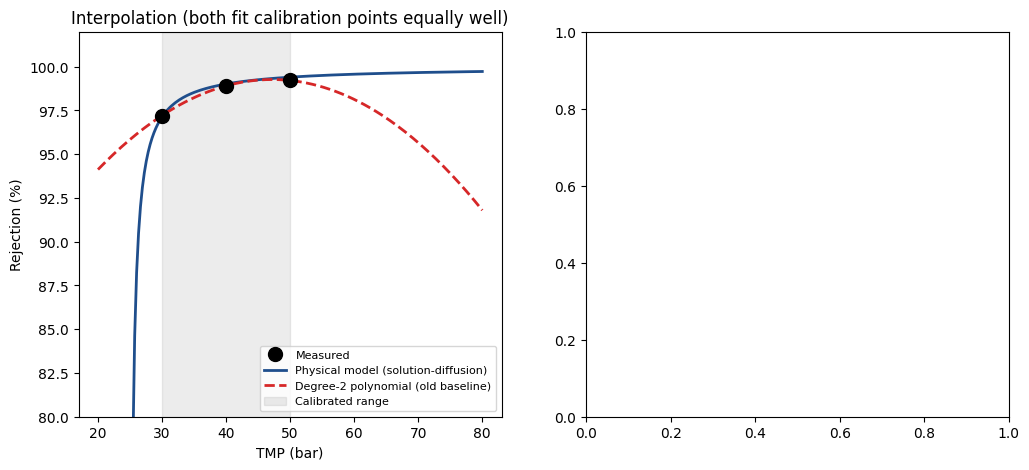

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.plot(TMP, rej_meas * 100, "o", ms=10, color="k", label="Measured", zorder=5)
ax.plot(tmp_grid, rej_physical_grid, "-", color="#1f4e8c", lw=2, label="Physical model (solution-diffusion)")
ax.plot(tmp_grid, rej_poly_grid, "--", color="#d62728", lw=2, label="Degree-2 polynomial (old baseline)")
ax.axvspan(30, 50, color="gray", alpha=0.15, label="Calibrated range")
ax.set_xlabel("TMP (bar)"); ax.set_ylabel("Rejection (%)")
ax.set_ylim(80, 102)
ax.set_title("Interpolation (both fit calibration points equally well)")
ax.legend(fontsize=8)

In [10]:
ax2 = axes[1]
ax2.plot(TMP, rej_meas * 100, "o", ms=10, color="k", label="Measured", zorder=5)
ax2.plot(tmp_grid, rej_physical_grid, "-", color="#1f4e8c", lw=2, label="Physical model")
ax2.plot(tmp_grid, rej_poly_grid, "--", color="#d62728", lw=2, label="Polynomial")
ax2.axvspan(30, 50, color="gray", alpha=0.15)
ax2.set_xlabel("TMP (bar)"); ax2.set_ylabel("Rejection (%)")
ax2.set_title("Extrapolation: polynomial is unphysical outside [30,50] bar")
ax2.legend(fontsize=8)
plt.suptitle("RO rejection vs TMP — physically-constrained model vs blind polynomial")
plt.tight_layout()
plt.savefig("plots/model2_improved_physical.png", dpi=150)
plt.show()

<Figure size 640x480 with 0 Axes>

In [11]:
print(f"\nAt 50 bar: physical model = {rejection_model(np.array([50.]), *popt)[0]*100:.2f}%,"
      f" polynomial = {poly_model.predict([[50]])[0]:.2f}%  (paper reports 99.2%)")
print(f"At 70 bar (extrapolation): physical model = {rejection_model(np.array([70.]), *popt)[0]*100:.2f}%,"
      f" polynomial = {poly_model.predict([[70]])[0]:.2f}%")
print(f"At 20 bar (below draw-solution osmotic pressure, ~24.9 bar): physical model correctly "
      f"saturates near 0 flux; polynomial = {poly_model.predict([[20]])[0]:.2f}% (can go negative/unphysical)")


At 50 bar: physical model = 99.40%, polynomial = 99.21%  (paper reports 99.2%)
At 70 bar (extrapolation): physical model = 99.67%, polynomial = 95.66%
At 20 bar (below draw-solution osmotic pressure, ~24.9 bar): physical model correctly saturates near 0 flux; polynomial = 94.12% (can go negative/unphysical)


In [12]:
with open("models/metrics_ro_rejection_improved.txt", "w") as f:
    f.write(f"Physical (solution-diffusion) model: A={A_fit:.4f}, B={B_fit:.5f}, R2 on 3 cal. points={r2_physical:.4f}\n")
    f.write(f"At 50 bar: physical={rejection_model(np.array([50.]),*popt)[0]*100:.2f}%, "
            f"polynomial={poly_model.predict([[50]])[0]:.2f}%, paper=99.2%\n")
    f.write(f"At 70 bar (extrapolation): physical={rejection_model(np.array([70.]),*popt)[0]*100:.2f}%, "
            f"polynomial={poly_model.predict([[70]])[0]:.2f}%\n")
    f.write(f"At 20 bar (extrapolation): physical={rejection_model(np.array([20.]),*popt)[0]*100:.2f}%, "
            f"polynomial={poly_model.predict([[20]])[0]:.2f}%\n")
    f.write("\nRationale: with n=3, both models fit the calibration points about equally well, so the\n"
            "correct axis of comparison is BEHAVIOR OUTSIDE the calibrated range, where the physical\n"
            "model stays monotonic/bounded and the polynomial does not.\n")
print("done")

done
